In [1]:
 #Mount your personal Google Drive to Colab
from google.colab import drive
drive.mount("/content/drive")
import os
os.chdir("drive")
os.chdir("MyDrive")
os.listdir()




Mounted at /content/drive


['Kunskapsskolan',
 'Privat',
 'Celsiusskolan',
 'Universitetet',
 'Kopia av IMG_9843.JPG',
 'Classroom',
 '59571c1a5721453aa412e28fda2fdbd4.mov',
 'Colab Notebooks',
 'SI_for_TA',
 'Examensgasque 2026']

In [2]:
if not os.path.isdir("SI_for_TA"): #create subfolder SI_for_TA does
  os.mkdir("SI_for_TA")
os.chdir("SI_for_TA")
os.getcwd()

'/content/drive/MyDrive/SI_for_TA'

Assignment 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

A1

a

In [3]:
N=20
my=5
sigma=2.7

D= np.random.normal(my, sigma, N)
print(D)

[4.2360811  5.98110744 2.01021394 2.02271712 9.59555368 3.53632128
 7.44664514 4.79083623 2.85274898 9.45461574 5.05885291 7.76830712
 6.28732154 4.48267877 5.13332291 5.05209574 3.55983399 4.18903386
 7.30284854 9.9844894 ]


b

In [4]:
m = np.mean(D)
s =np.std(D)
print(m)
print(s)

5.53728127145626
2.343220211043989


c

In [5]:
B= 1000
boot_means = []
boot_stds = []

for _ in range(B):
    sample = np.random.choice(D, size=N, replace=True)
    boot_means.append(np.mean(sample))
    boot_stds.append(np.std(sample, ddof=1))

boot_means = np.array(boot_means)
boot_stds = np.array(boot_stds)
print(boot_means)
print(boot_stds)

[5.03882065 5.53281077 5.75587658 5.13457454 5.55978145 5.63068824
 6.42229951 4.78055269 6.23065431 4.84950359 6.51719648 4.75416194
 5.22799731 4.67299785 6.71032332 5.23319127 4.81065461 4.74390834
 5.89240192 5.22772714 5.30484149 5.19727481 5.80710004 5.2025592
 5.54110681 5.57275537 6.17242658 5.01960428 6.00768958 6.24002367
 5.86135502 6.4491473  4.93581744 5.95830076 5.71484578 5.89356873
 5.14149327 5.79030111 4.68300106 5.17889892 5.72282918 5.87330041
 6.06723671 5.44416284 5.76326632 5.74548448 5.60202834 5.49329909
 5.63515925 4.75826211 5.14726903 6.44060981 6.01751353 4.10856005
 4.9931431  4.99434977 5.56396206 5.70601198 4.63961798 6.02979332
 6.10222556 6.21086681 5.99686766 4.68904281 5.69964105 5.89325122
 4.73019052 6.23196802 6.02722106 4.55338444 5.2394357  5.186824
 4.73370104 5.7718578  6.06988892 5.74168477 6.44079529 5.5479988
 5.55038081 5.98292473 5.28176885 5.99641848 5.34227073 6.14532734
 6.12206384 5.53988747 5.58103263 6.11048391 5.05152593 5.77503554

d

In [6]:
a20 = np.percentile(boot_means, 2.5)
b20 = np.percentile(boot_means, 97.5)
print(a20)
print(b20)

4.532011240720902
6.610523156245898


e

In [7]:
N = 2000
D = np.random.normal(my, sigma, N)

m = np.mean(D)
s = np.std(D, ddof=1)

boot_means = []

for _ in range(B):
    sample = np.random.choice(D, size=N, replace=True)
    boot_means.append(np.mean(sample))

a2000 = np.percentile(boot_means, 2.5)
b2000 = np.percentile(boot_means, 97.5)

print("Bootstrap CI (N=2000):", a2000, b2000)

Bootstrap CI (N=2000): 4.913134862110618 5.15274865970797


Since N is bigger, the variation will be smaller which leads to a smaller interval

A2

In [8]:
X = np.array([13.2, 8.2, 10.9, 14.3, 10.7, 6.6, 9.5, 10.8, 8.8, 13.3])
Y = np.array([14.0, 8.8, 11.2, 14.2, 11.8, 6.4, 9.8, 11.3, 9.3, 13.6])

a

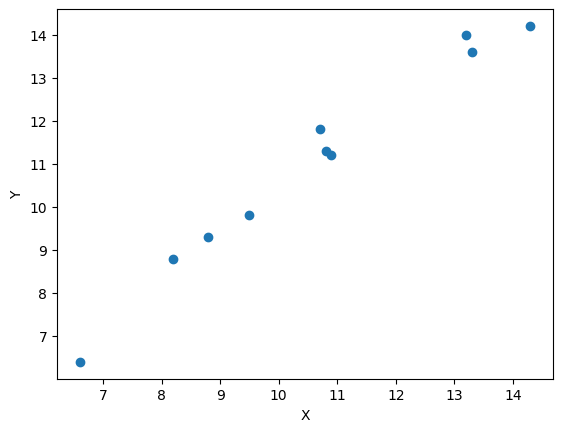

In [9]:
plt.scatter(X, Y)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

The strong possitive correlation suggest that the variables are related.

b

In [10]:
pearson = np.corrcoef(X, Y)[0,1]
print("Correlation:", pearson)

Correlation: 0.9882255304736491


The value is close to 1 which indicates an almost perfect positive linear relationship

c

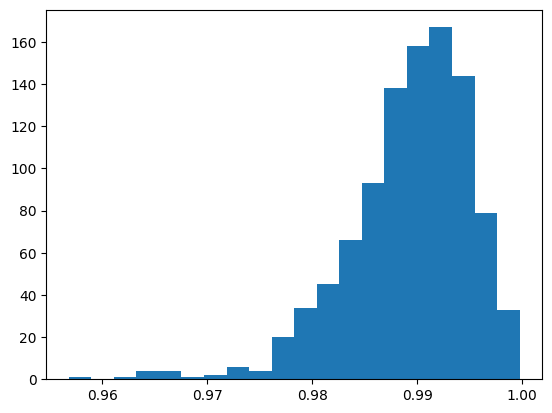

95% CI: 0.9767105247154368 0.9979906111263284


In [11]:
B = 1000
boot_corr = []

data = list(zip(X, Y))
for _ in range(B):
    sample = np.random.choice(len(data), size=10, replace=True)
    Xb = X[sample]
    Yb = Y[sample]
    boot_corr.append(np.corrcoef(Xb, Yb)[0,1])

boot_corr = np.array(boot_corr)

plt.hist(boot_corr, bins=20)
plt.show()

a = np.percentile(boot_corr, 2.5)
b = np.percentile(boot_corr, 97.5)

print("95% CI:", a, b)

since the interval does not contain 0, it is a significante correlation between y and x

A3

a

In [12]:
np_values = np.array(['red', 'white'])
np_count = np.array([14,46])
urn = np.repeat(np_values, np_count)



b

In [15]:
times = 10000
frac = []

np.random.seed(42)

for i in range(N):
    np_draw_with_replacement = np.random.choice(urn, size=60, replace=True)
    mutations = np.sum(np_draw_with_replacement == 'red')
    frac.append(mutations/ 60)

c

In [16]:
frac = np.array(frac)
a = np.percentile(frac, 2.5)
b = np.percentile(frac, 97.5)

d

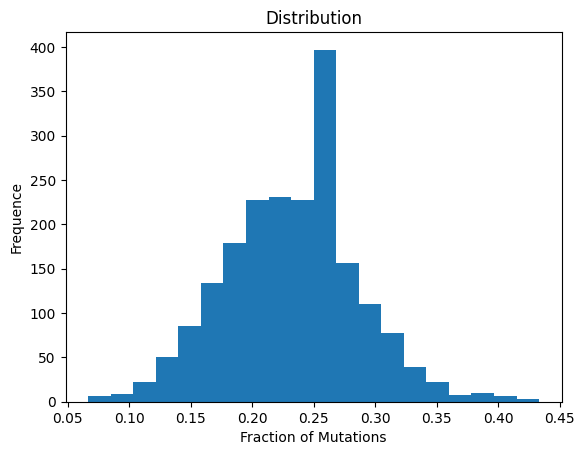

In [18]:
plt.hist(frac, bins=20)
plt.title('Distribution')
plt.xlabel('Fraction of Mutations')
plt.ylabel('Frequence')
plt.show()

e

In [23]:

print(f"[{a:.4f}, {b:.4f}]")

[0.1333, 0.3333]


A4

In [28]:
np_values = np.array(['red', 'white'])
np_count = np.array([89, 7])
np_urn = np.repeat(np_values, np_count)

N = 1000
successes_frac = []

np.random.seed(42)

for i in range(N):
  np_draw_with_replacement = np.random.choice(np_urn, size=96, replace=True)
  successes = np.sum(np_draw_with_replacement == 'red')
  successes_frac.append(successes/96)

successes_frac = np.array(successes_frac)
a = np.percentile(successes_frac, 2.5)
b = np.percentile(successes_frac, 97.5)

print(f" [{a:.4f}, {b:.4f}]")

 [0.8747, 0.9690]


B1

a

In [30]:
np_values = np.array(['red', 'white'])
np_count = np.array([1, 1])
np_urn = np.repeat(np_values, np_count)

N = 1000

less_than_7 = 0

np.random.seed(42)

for i in range(N):
  np_draw_with_replacement = np.random.choice(np_urn, size=20, replace=True)
  if np.sum(np_draw_with_replacement == 'red') <= 7:
    less_than_7 += 1

p_value = less_than_7 / N
print(p_value)



0.13


Since the p-value is bigger than the standard significance level of 5%, we can't reject the hypothesis that the classifier is guessing

b2

a

In [31]:
np_values = np.array(['red', 'white'])
np_count = np.array([88, 12])
np_urn = np.repeat(np_values, np_count)

N = 1000

less_than_900 = 0

np.random.seed(42)

for i in range(N):
  np_draw_with_replacement = np.random.choice(np_urn, size=1200, replace=True)
  if np.sum(np_draw_with_replacement == 'red') <= 900:
    less_than_900 += 1

p_value = less_than_900 / N
print(f"p-value: {p_value:.4f}")

p-value: 0.0000


p-value is/close to zero --> claim can be rejected

b

In [34]:
values = np.array(['red', 'white'])
count = np.array([88, 12])
urn = np.repeat(values, count)

N = 1000

less_than_9 = 0

np.random.seed(42)

for i in range(N):
  draw_with_replacement = np.random.choice(urn, size=12, replace=True)
  if np.sum(draw_with_replacement == 'red') <= 9:
    less_than_9 += 1

p_value = less_than_9 / N
print(p_value)

0.161


The p-values has risen a lot with the smaller sample size --> null hypothetis cant be rejected at 5% SL

b3

In [36]:
women =[60,62,73,81,27,72,61,59,42,39,71,74]
men =[74,79,80,89,71,72,92,67,91,83,43]

m_woman = np.mean(women)
m_man = np.mean(men)
d_obs = m_woman - m_man

urn = women + men

N = 10000
d_sim = []

np.random.seed(42)

for i in range(N):
    simulate_women = np.random.choice(urn, size=12, replace=True)
    simulate_men = np.random.choice(urn, size=11, replace=True)
    d_sim.append(np.mean(simulate_women) - np.mean(simulate_men))
d_sim = np.array(d_sim)

p_value = np.sum(np.abs(d_sim) >= np.abs(d_obs)) / N
print(p_value)

0.0182


b4

0.9606


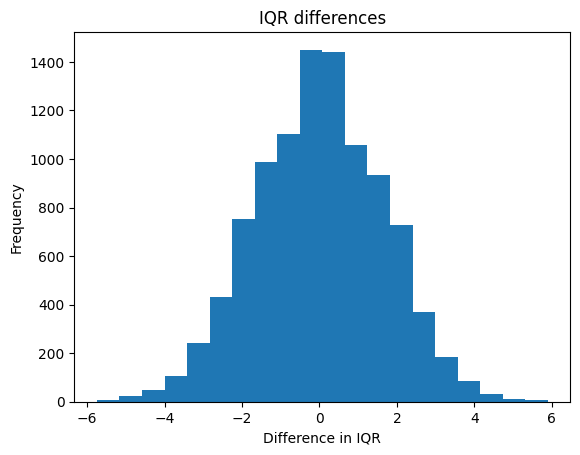

In [39]:
values_of_group_A = [13.2, 8.2, 10.9, 14.3, 10.7, 6.6, 9.5, 10.8, 8.8, 13.3]
values_of_group_B = [14.0, 8.8, 11.2, 14.2, 11.8, 6.4, 9.8, 11.3, 9.3, 13.6]

IQR1 = np.percentile(values_of_group_A, 75) - np.percentile(values_of_group_A, 25)
IQR2 = np.percentile(values_of_group_B, 75) - np.percentile(values_of_group_B, 25)
d_obs = IQR1 - IQR2

urn = values_of_group_A + values_of_group_B

N = 10**4

d_sim = []

np.random.seed(42)

for i in range(N):
    simulate_A = np.random.choice(urn, size=10, replace=True)
    simulate_B = np.random.choice(urn, size=10, replace=True)
    IQR1_sim = np.percentile(simulate_A, 75) - np.percentile(simulate_A, 25)
    IQR2_sim = np.percentile(simulate_B, 75) - np.percentile(simulate_B, 25)
    d_sim.append(IQR1_sim - IQR2_sim)


d_sim = np.array(d_sim)

p_value = np.sum(np.abs(d_sim) >= np.abs(d_obs)) / N
print(p_value)

plt.hist(d_sim, bins=20)
plt.title('IQR differences')
plt.xlabel('Difference in IQR')
plt.ylabel('Frequency')
plt.show()

since the p-value is close to 1, we cant reject the null hypothesis. There is therefore no statistically signficant evidence that there is a difference in mrna IQR between the species